In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

In [4]:
USAGE_CSV = "gen8ou_usage.csv"
ITEMS_CSV = "gen8ou_items.csv"
TEAM_CSV = "gen8ou_teams.csv"

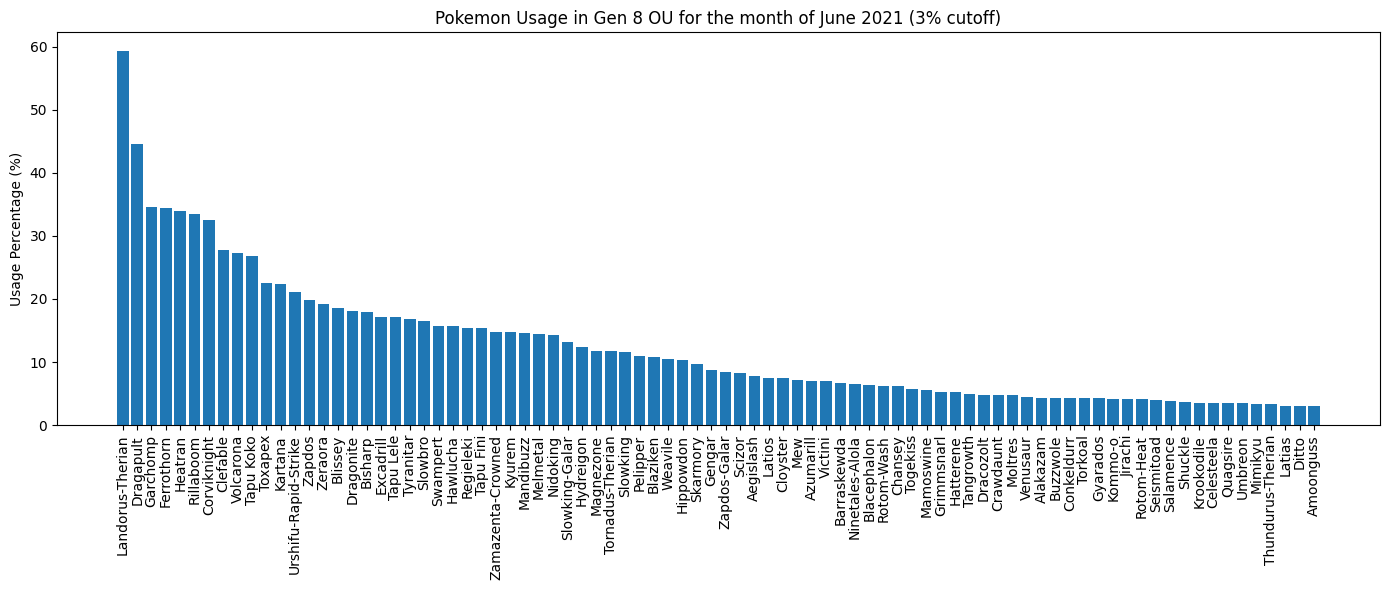

Number of Pokémon with over 10% usage: 40


In [9]:
usage_df = pd.read_csv(USAGE_CSV)

total_battles = usage_df["total_battles"].iloc[0]
usage_df["raw_percent"] = (usage_df["raw_usage"] / total_battles) * 100
filtered = usage_df[usage_df["raw_percent"] >= 3.0]
filtered = filtered.sort_values("raw_percent", ascending=False)

plt.figure(figsize=(14,6))
plt.bar(filtered["pokemon"], filtered["raw_percent"])
plt.xticks(rotation=90)
plt.ylabel("Usage Percentage (%)")
plt.title("Pokemon Usage in Gen 8 OU for the month of June 2021 (3% cutoff)")
plt.tight_layout()
plt.show()
over_10_count = (usage_df["raw_percent"] > 10.0).sum()
print("Number of Pokémon with over 10% usage:", over_10_count)

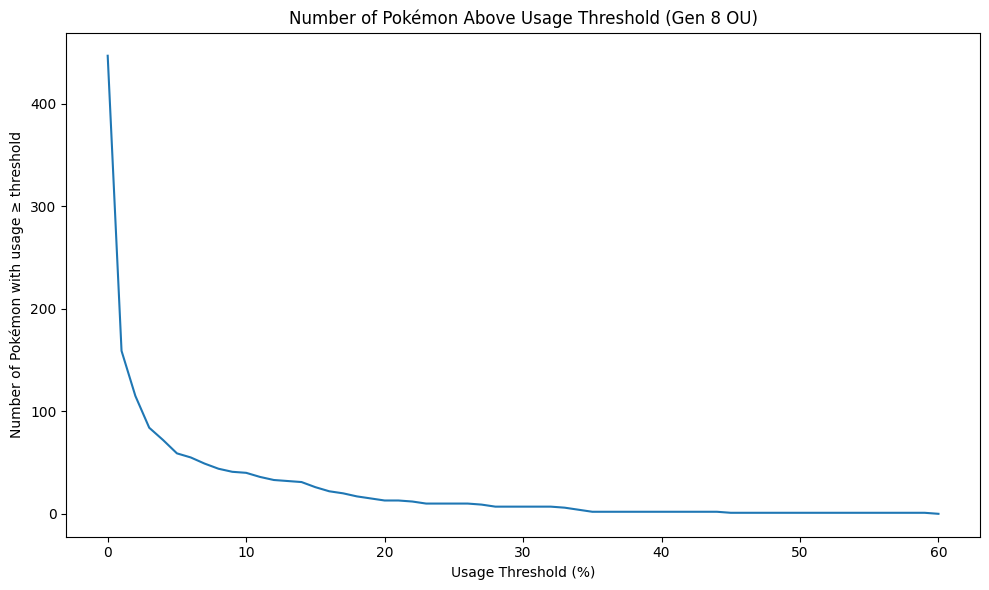

In [ ]:
usage_df = pd.read_csv(USAGE_CSV)

total_battles = usage_df["total_battles"].iloc[0]
usage_df["raw_percent"] = (usage_df["raw_usage"] / total_battles) * 100

max_usage = usage_df["raw_percent"].max()
thresholds = np.arange(0, max_usage + 1, 1)
counts = [(usage_df["raw_percent"] >= t).sum() for t in thresholds]

plt.figure(figsize=(10,6))
plt.plot(thresholds, counts)
plt.xlabel("Usage Threshold (%)")
plt.ylabel("Number of Pokémon with usage ≥ threshold")
plt.title("Number of Pokémon Above Usage Threshold (Gen 8 OU)")
plt.tight_layout()
plt.show()